In [14]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

import sys
sys.path.append("/data/aurelien/local/git/certes_lissi/LP_NN")
from test_cvxpy_3_bus_24hrs_battery_PV import * # AH: this is new
from test_cvxpy_9_bus_24hrs_battery_PV import create_certes_case_9bus,_get_idx


def load_results(file_path):
    """
    Load results from a pickle file.

    Args:
        file_path (str): Path to the pickle file.

    Returns:
        dict: Dictionary containing the loaded results.
    """
    try:
        with open(file_path, 'rb') as f:
            results = pickle.load(f)
        return results
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None 

In [ ]:
def metric_battery_usage(Y_final,d,nbus=3,debug=True):
    """
    NB:this type of metric can't be coded in Evaluator
    because it is problem-specific (e.g. would be meaningless for random QP).
    """
    warnings.warn('NOT COHERENT WITH inference_plot_compare_classical.py error somewher ???')
    fig,ax = plt.subplots(1,1)
    if nbus==3:
        #copied from test_cvxpy_3_bus_24hrs_battery_PV.py
        def get_e_batt_idx(t, batt_idx,num_vars_per_period,N_G,N_B,N_BATT):
            """
            Returns the global index in the 'y' vector for battery 'batt_idx'
            (0-indexed) energy (SOC) at time period 't' (0-indexed).
            """
            return t * num_vars_per_period + N_G + N_B + 2 * N_BATT + batt_idx
        N_B = 3  # Number of buses
        N_G = 2  # Number of generators
        N_BATT = 1 # Number of battery storage units
        T = d['T']
        num_vars_per_period = d['num_vars_per_period']
        e_init = d['battery_data'][0]['E_initial']
        batt_idx=0
        e_batt_k=[]
        delta_e_max_l = []
        for i in range(Y_final.shape[0]):
            y = Y_final[i,:]
            e_batt_k=[]
            for t in range(T):        
                e_batt_k_idx =get_e_batt_idx(t, batt_idx,num_vars_per_period,N_G,N_B,N_BATT)
                e_batt_k.append(  y[e_batt_k_idx] )    
            e_batt_k = np.array(e_batt_k)  
            delta_e_max = 100*np.max(np.abs(e_batt_k-e_init))/e_init 
            delta_e_max_l.append(delta_e_max )
            if debug: ax.plot(e_batt_k)  
        print('max ch/dis |E-E0|/E0 (%)=',np.mean(delta_e_max_l))

    elif nbus==9:
        S_BASE = 100.
        nvpp  = d['num_vars_per_period']
        N_B  = d['N_B']
        N_G  = d['N_G']
        N_BATT = d['N_BATT']
        T = d['T']
        e_init = d['battery_data'][0]['E_initial']*S_BASE

        delta_e_max_l = []
        for i in range(Y_final.shape[0]):
            y = Y_final[i,:]
            e_batt_k=[]
            for t in range(T): 
                e_batt_k_idx  =  _get_idx(t, 'e', N_G, N_B, N_BATT, nvpp)
                e_batt_k.append(  y[e_batt_k_idx] * S_BASE)
            e_batt_k = np.array(e_batt_k)
            delta_e_max = 100*np.max(np.abs(e_batt_k-e_init))/e_init 
            delta_e_max_l.append(delta_e_max )
            if debug: ax.plot(e_batt_k)  
        print('max ch/dis |E-E0|/E0 (%)=',np.mean(delta_e_max_l))

    else:
        raise ValueError
    if debug: plt.show()


In [ ]:
method = "penalty"#"DC3"##"FSNet" #
prob_type = "convex"
prob_name = "qp"
seed = 2025
#fname = "Problem-100-50-50-10000"
#fname = "Problem-360-432-288-10000"
fname = "Problem-192-238-120-10000"
#dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-100-50-50-10000/MLP_{method}/results_seed{seed}.pkl"
#dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-192-238-120-1000/MLP_{method}/results_seed{seed}.pkl"
dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}{fname}/MLP_{method}/results_seed{seed}.pkl"

results = load_results(dir_path)
Y_final = results['test_results']['detailed_results_all_batch_sizes'][256][0]['Y_final']
#results['test_results']['detailed_results_all_batch_sizes'][256][0].keys()

dict_keys(['X', 'Y_pred', 'Y_pred_scaled', 'Y_final', 'Y_true', 'metrics'])

method=penalty nbus=3


/tmp/ipykernel_13472/3596548557.py:6: UserWarning: NOT COHERENT WITH inference_plot_compare_classical.py error somewher ???
  warnings.warn('NOT COHERENT WITH inference_plot_compare_classical.py error somewher ???')


max ch/dis |E-E0|/E0 (%)= 21.172108856188732


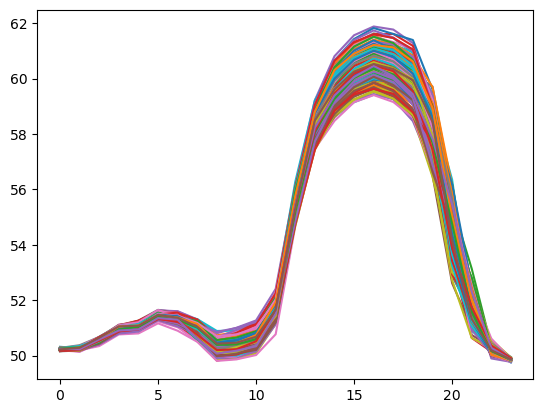

method=DC3 nbus=3
max ch/dis |E-E0|/E0 (%)= 19.996312529704728


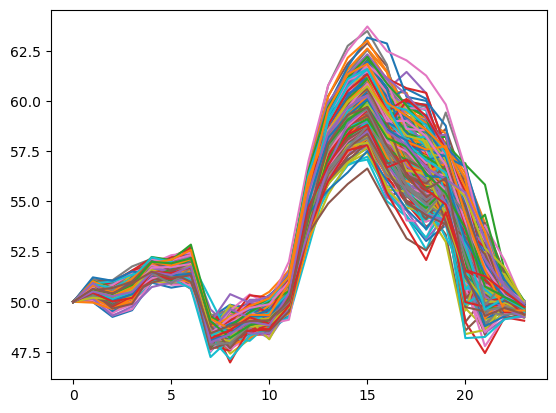

method=skm nbus=3
max ch/dis |E-E0|/E0 (%)= 20.813938653142223


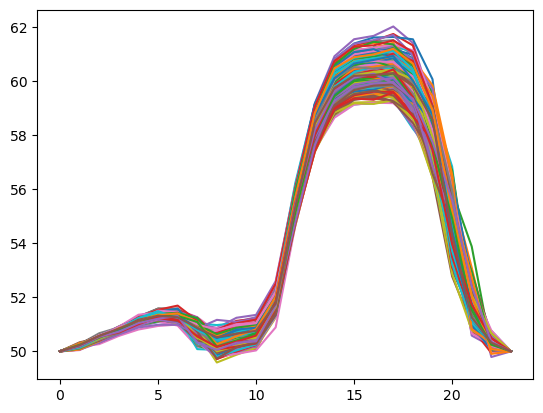

In [27]:
#method = "penalty"#"DC3"##"FSNet" #
prob_type = "convex"
prob_name = "qp"
seed = 2025
#fname = "Problem-100-50-50-10000"
#fname = "Problem-360-432-288-10000"
nbus=3; fname = "Problem-192-238-120-10000"; method_l = ["penalty", "DC3", "skm"]
#nbus=9;fname = "Problem-360-432-288-10000"; method_l = ["penalty",  "skm"]
#dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-100-50-50-10000/MLP_{method}/results_seed{seed}.pkl"
#dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-192-238-120-1000/MLP_{method}/results_seed{seed}.pkl"


for method in method_l:
        dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}{fname}/MLP_{method}/results_seed{seed}.pkl"
        results = load_results(dir_path)
        Y_final = results['test_results']['detailed_results_all_batch_sizes'][256][0]['Y_final']

        if nbus==3:
                d = create_certes_case_3bus()
                #plot(results,d) # new function
        elif nbus==9:
                d= create_certes_case_9bus(noise_demand=None, noise_pv_gen=None)
        print('======\nmethod={} nbus={}'.format(method,nbus))
        metric_battery_usage(Y_final,d,nbus=nbus)

In [ ]:
print(results.keys())
#print(results['training_time_seconds'])


dict_keys(['seed', 'method', 'config', 'timestamp', 'training_time_seconds', 'train_history', 'val_history', 'test_results', 'pytorch_version', 'device_used'])


tensor([[ 2.1699e+01,  0.0000e+00,  2.5755e-03,  ...,  5.2566e-03,
          1.9988e+01,  4.9891e+01],
        [ 2.2667e+01,  0.0000e+00,  3.5681e-04,  ...,  5.3038e-03,
          1.9988e+01,  4.9882e+01],
        [ 2.2806e+01,  0.0000e+00,  2.0556e-02,  ...,  6.2128e-03,
          1.9987e+01,  4.9857e+01],
        ...,
        [ 2.1166e+01,  0.0000e+00, -1.4137e-02,  ...,  5.4705e-03,
          1.9987e+01,  4.9904e+01],
        [ 2.2677e+01,  0.0000e+00,  2.1221e-03,  ...,  4.4165e-03,
          1.9990e+01,  4.9847e+01],
        [ 2.0794e+01,  0.0000e+00, -3.9651e-02,  ...,  4.6811e-03,
          1.9989e+01,  4.9861e+01]], dtype=torch.float64)

classical solver solve time
-------------

run this on **LISSI SERVER**

In [ ]:
# run this on LISSI SERVER  datasets/convex/qp dir
import pickle
#filepath = "random2025_qp_dataset_var100_ineq50_eq50_ex10000"
filepath = "random2025_qp_dataset_var192_ineq238_eq120_ex10000"
filepath = "random2025_qp_dataset_var360_ineq432_eq288_ex1000"
with open(filepath, 'rb') as f:
        data = pickle.load(f)
print('solve_time_avg=', data['solve_time_avg'])
print('solve_time_std=', data['solve_time_std']  )

FileNotFoundError: [Errno 2] No such file or directory: 'random2025_qp_dataset_var360_ineq432_eq288_ex1000'

training convergence
------------

<Axes: >

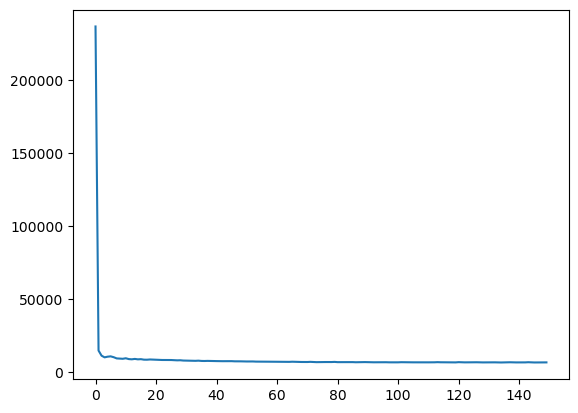

In [ ]:
# 1 ALGO ONLY (see below for ALL ALGO)
#results['train_history']
df = pd.DataFrame(results['train_history'])
df
df.loss.plot()

convex/qp/QPProblem-192-238-120-10000/MLP_penalty/results_seed2025.pkl
convex/qp/QPProblem-192-238-120-10000/MLP_DC3/results_seed2025.pkl
convex/qp/QPProblem-192-238-120-10000/MLP_skm/results_seed2025.pkl


<Axes: >

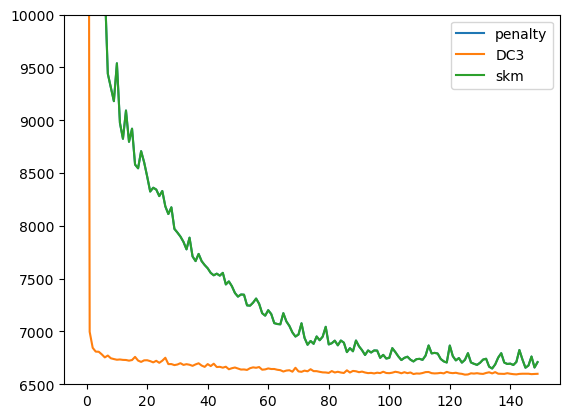

In [15]:
# ALL ALGO
prob_type = "convex"
prob_name = "qp"
row_l = []
seed = 2025
#algo_l = ['DC3','FSNet','skm']
#algo_l = ['penalty','FSNet','DC3','skm']
algo_l = ['penalty','DC3','skm']
#algo_l = ['penalty','skm']
#algo_l = ['FSNet']
batch_size = 256
#fname = "Problem-100-50-50-10000"
fname = "Problem-192-238-120-10000"
#fname ="Problem-360-432-288-10000"
df_all=pd.DataFrame()
for i,method in enumerate(algo_l):
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-100-50-50-10000/MLP_{method}/results_seed{seed}.pkl"
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-192-238-120-1000/MLP_{method}/results_seed{seed}.pkl"
    dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}{fname}/MLP_{method}/results_seed{seed}.pkl"
    print(dir_path)
    results = load_results(dir_path)
    # Get batch comparison data from the loaded results
    #batch_comparison = results['test_results']['batch_size_comparison']
    # get only batchsize 256
    #metrics = (results['test_results']['batch_size_comparison'].pop(batch_size))['metrics']
    df = pd.DataFrame(results['train_history'])
    df = df.loss
    df_all[method]=df
    

df_all
df_all.plot(ylim=[6500,10000])
   

In [13]:
df_all

,penalty,DC3,skm
0,237039.463751,22457.742363,237039.463751
1,14822.249108,6996.922559,14822.249108
2,11307.330721,6845.336046,11307.330721
3,10165.380233,6809.418172,10165.380233
4,10623.697485,6807.985427,10623.697485
...,...,...,...
145,6656.650550,6600.034784,6656.650550
146,6677.917546,6599.819771,6677.917546
147,6762.845903,6596.092951,6762.845903
148,6658.929504,6597.707755,6658.929504


training time
-------------

In [20]:
# can be misleading, if nb epoch not adapted 
print(results.keys())
print(results['training_time_seconds'])
print(results['timestamp'])

dict_keys(['seed', 'method', 'config', 'timestamp', 'training_time_seconds', 'train_history', 'val_history', 'test_results', 'pytorch_version', 'device_used'])
123.14951848983765
2026-02-18 15:35:47


In [21]:
# just added 'epoch_time' field
# NB: this is training time, different from inference time below
df = pd.DataFrame(results['train_history'])
try:
   print('training epoch_time.mean=', df.epoch_time.mean() )
except:
   print("df.epoch_time NOT AVAILABLE !!!!!")

training epoch_time.mean= 0.8205177640914917


test-time metrics: 1 algo
---------

In [ ]:
def results_to_readable(results):
    # Get batch comparison data from the loaded results
    batch_comparison = results['test_results']['batch_size_comparison']

    # Create a more readable DataFrame by expanding the metrics
    readable_data = []
    for batch_size, data in batch_comparison.items():
        metrics = data['metrics']
        row = {'Method': method,
            'Batch Size': batch_size,
            'Opt Gap Mean (\%)': f"{metrics['opt_gap_mean']*100:.4f}",
            #'Opt Gap Std (\%)': f"{metrics['opt_gap_std']*100:.4f}",
            'Opt Gap Std (\%)': f"{metrics['opt_gap_std']*100:.2e}",
            'Opt Gap Max (\%)': f"{metrics['opt_gap_max']*100:.4f}",
            'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
            'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
            'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
            'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
            'Average Batch inference time (s)': f"{metrics['avg_inference_time']:.4f}",
        }
        readable_data.append(row)

    df_readable = pd.DataFrame(readable_data)
    return df_readable
df_readable = results_to_readable(results)
df_readable_styled = df_readable.style.set_properties(**{'text-align': 'center'})
display(df_readable_styled)
print(df_readable.T.to_latex())

<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:11: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_7868/1554352898.py:11: SyntaxWarning: invalid escape sequence '\%'
  'Opt Gap Mean (\%)': f"{metrics['opt_gap_mean']*100:.4f}",
/tmp/ipykernel_7868/1554352898.py:13: SyntaxWarning: invalid escape sequence '\%'
  'Opt Gap Std (\%)': f"{metrics['opt_gap_std']*100:.2e}",
/tmp/ipykernel_7868/1554352898.py:14: SyntaxWarning: invalid escape sequence '\%'
  'Opt Gap Max (\%)': f"{metrics['opt_gap_max']*100:.4f}",


,Method,Batch Size,Opt Gap Mean (\%),Opt Gap Std (\%),Opt Gap Max (\%),Eq Violation Mean,Eq Violation Max,Ineq Violation Mean,Ineq Violation Max,Average Batch inference time (s)
0,penalty,256,-99.9769,2.30e-06,-99.9767,7.36e+01,7.40e+01,0.00e+00,0.00e+00,0.0003
1,penalty,512,-99.9769,0.00e+00,-99.9767,7.36e+01,7.40e+01,0.00e+00,0.00e+00,0.0003


\begin{tabular}{lll}
\toprule
 & 0 & 1 \\
\midrule
Method & penalty & penalty \\
Batch Size & 256 & 512 \\
Opt Gap Mean (\%) & -99.9769 & -99.9769 \\
Opt Gap Std (\%) & 2.30e-06 & 0.00e+00 \\
Opt Gap Max (\%) & -99.9767 & -99.9767 \\
Eq Violation Mean & 7.36e+01 & 7.36e+01 \\
Eq Violation Max & 7.40e+01 & 7.40e+01 \\
Ineq Violation Mean & 0.00e+00 & 0.00e+00 \\
Ineq Violation Max & 0.00e+00 & 0.00e+00 \\
Average Batch inference time (s) & 0.0003 & 0.0003 \\
\bottomrule
\end{tabular}



test-time metrics: all algo
---------

In [8]:
row_l = []
seed = 2025
prob_type = "convex"
prob_name = "qp"
#algo_l = ['DC3','FSNet','skm']
#algo_l = ['penalty','FSNet','DC3','skm']
algo_l = ['penalty','DC3','skm']
algo_l = ['penalty','skm']
#algo_l = ['FSNet']
batch_size = 256
#fname = "Problem-100-50-50-10000"
#fname = "Problem-192-238-120-10000"
fname ="Problem-360-432-288-10000"
for method in algo_l:
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-100-50-50-10000/MLP_{method}/results_seed{seed}.pkl"
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-192-238-120-1000/MLP_{method}/results_seed{seed}.pkl"
    dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}{fname}/MLP_{method}/results_seed{seed}.pkl"
    print(dir_path)
    results = load_results(dir_path)
    # Get batch comparison data from the loaded results
    batch_comparison = results['test_results']['batch_size_comparison']
    # get only batchsize 256
    metrics = (results['test_results']['batch_size_comparison'].pop(batch_size))['metrics']
    # AH !!!!!!
    avg_sample_time = metrics['avg_inference_time']/batch_size
    row = {
        'Algorithm': method,
            'true cost (€)': f"{metrics['true_objective']*100:.2e}",
            'cost (€)': f"{metrics['objective']*100:.2e}",
            'Opt Gap Mean (\%)': f"{metrics['opt_gap_mean']*100:.4f}",
            #'Opt Gap Std (\%)': f"{metrics['opt_gap_std']*100:.4f}",
            #'Opt Gap Std (\%)': f"{metrics['opt_gap_std']*100:.2e}",
            'Opt Gap Max (\%)': f"{metrics['opt_gap_max']*100:.4f}",
            'Eq Viol Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
            'Eq Viol Max': f"{metrics['eq_violation_l1_max']:.2e}",
            'Ineq Viol Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
            'Ineq Viol Max': f"{metrics['ineq_violation_l1_max']:.2e}",
            'Sample inference time (s)': f"{avg_sample_time:.2e}",
            'Train time(s)':   f"{results['training_time_seconds']:.2e}"
        
    }
    row_l.append(row)

df = pd.DataFrame(row_l)
#print(df)
print(df.T.to_latex())

<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:33: SyntaxWarning: invalid escape sequence '\%'
<>:30: SyntaxWarning: invalid escape sequence '\%'
<>:33: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_8976/2554915536.py:30: SyntaxWarning: invalid escape sequence '\%'
  'Opt Gap Mean (\%)': f"{metrics['opt_gap_mean']*100:.4f}",
/tmp/ipykernel_8976/2554915536.py:33: SyntaxWarning: invalid escape sequence '\%'
  'Opt Gap Max (\%)': f"{metrics['opt_gap_max']*100:.4f}",


convex/qp/QPProblem-360-432-288-10000/MLP_penalty/results_seed2025.pkl
convex/qp/QPProblem-360-432-288-10000/MLP_skm/results_seed2025.pkl
\begin{tabular}{lll}
\toprule
 & 0 & 1 \\
\midrule
Algorithm & penalty & skm \\
true cost (€) & 1.02e+07 & 1.02e+07 \\
cost (€) & 2.34e+03 & 1.05e+07 \\
Opt Gap Mean (\%) & -99.9769 & 3.8128 \\
Opt Gap Max (\%) & -99.9767 & 3.8358 \\
Eq Viol Mean & 7.36e+01 & 2.01e-12 \\
Eq Viol Max & 7.40e+01 & 2.03e-12 \\
Ineq Viol Mean & 0.00e+00 & 3.71e-21 \\
Ineq Viol Max & 0.00e+00 & 4.34e-19 \\
Sample inference time (s) & 1.22e-06 & 1.87e-03 \\
Train time(s) & 1.23e+02 & 1.24e+02 \\
\bottomrule
\end{tabular}



seed variability
------------------

In [ ]:

seed_l = [2025,2025]
row_l = []
for seed in seed_l:
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-100-50-50-10000/MLP_{method}/results_seed{seed}.pkl"
    #dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}Problem-192-238-120-1000/MLP_{method}/results_seed{seed}.pkl"
    dir_path = f"{prob_type}/{prob_name}/{prob_name.upper()}{fname}/MLP_{method}/results_seed{seed}.pkl"
    results = load_results(dir_path)
    # Get batch comparison data from the loaded results
    batch_comparison = results['test_results']['batch_size_comparison']
    # get only batchsize 256
    metrics = (results['test_results']['batch_size_comparison'].pop(256))['metrics']
    # 
    row = {
        'Opt Gap Mean (%)': metrics['opt_gap_mean']*100,
        'Opt Gap Std (%)': metrics['opt_gap_std']*100,
        'Opt Gap Max (%)': metrics['opt_gap_max']*100,
        'Eq Violation Mean': metrics['eq_violation_l1_mean'],
        'Eq Violation Max': metrics['eq_violation_l1_max'],
        'Ineq Violation Mean': metrics['ineq_violation_l1_mean'],
        'Ineq Violation Max': metrics['ineq_violation_l1_max'],
        'Average Batch inference Time (s)': metrics['avg_inference_time'],
    }
    row_l.append(row)

df = pd.DataFrame(row_l)
#print(df)
print('STD over realizations:\n')
print(df.std(axis=0).T)

STD over realizations:

Opt Gap Mean (%)                    0.0
Opt Gap Std (%)                     0.0
Opt Gap Max (%)                     0.0
Eq Violation Mean                   0.0
Eq Violation Max                    0.0
Ineq Violation Mean                 0.0
Ineq Violation Max                  0.0
Average Batch inference Time (s)    0.0
dtype: float64


In [46]:
metrics

{'ineq_violation_l1_mean': 7.579644772244737,
 'eq_violation_l1_max': 7.6996463896565e-13,
 'opt_gap_mean': 0.003252167389391278,
 'opt_gap_std': 0.0,
 'eq_violation_l2_max': 2.2994219401745706e-26,
 'ineq_violation_l1_max': 11.553908975497043,
 'solution_distance_max': 1249.8390866023585,
 'eq_violation_l1_mean': 5.506841251732192e-13,
 'opt_gap_min': 0.0010788242820738859,
 'ineq_violation_l2_max': 15.61398690267724,
 'ineq_violation_max_max': 3.07336031011288,
 'solution_distance_mean': 572.142935063266,
 'objective': 6587.043134130591,
 'opt_gap_max': 0.005391351267692645,
 'eq_violation_l2_mean': 7.480583341440109e-27,
 'solution_distance_std': 0.0,
 'ineq_violation_max_mean': 1.5459588320440505,
 'eq_violation_max_mean': 3.432809592140984e-14,
 'eq_violation_max_max': 8.881784197001252e-14,
 'true_objective': 6565.725084424895,
 'ineq_violation_l2_mean': 7.4865112796324915,
 'total_time': 0.24605822563171387,
 'avg_inference_time': 0.24605822563171387}